DecisionTreeClassifier: a custom built class implementation for the decision tree classifier logic.

src.shared imports: \
numpy as np \
pandas as pd \
matplotlib.pyplot as plt \
utils like load_dataset, calculating metrics, etc.

In [5]:
import sys
from pathlib import Path

project_root = str(Path.cwd().parents[1])

if project_root not in sys.path:
    sys.path.insert(0, project_root)

from src.classification.decision_tree import DecisionTreeClassifier
from src.shared import *

I chose a dataset suitable for classification. \
The moons dataset fits this criterion well and is perfect for demonstrating the decision tree classifier.

         x1        x2        x3  label
0 -0.926767 -0.111073  0.086017      0
1 -0.917583  0.706006  0.058041      0
2  0.437984  0.899093  0.072543      0
3  0.089694  0.291446  0.070444      1
4  0.110672 -0.070806 -0.090376      1 

Statistics:
               x1          x2          x3       label
count  200.000000  200.000000  200.000000  200.000000
mean     0.499625    0.242255   -0.007900    0.500000
std      0.864680    0.505837    0.060073    0.501255
min     -1.082877   -0.671388   -0.099842    0.000000
25%     -0.066660   -0.182419   -0.059922    0.000000
50%      0.517917    0.215962   -0.010587    0.500000
75%      1.044591    0.696222    0.040636    1.000000
max      2.148725    1.168358    0.099933    1.000000

Average measurements per moon:

             x1        x2        x3
label                              
0      0.009971  0.621211 -0.005318
1      0.989279 -0.136701 -0.010482


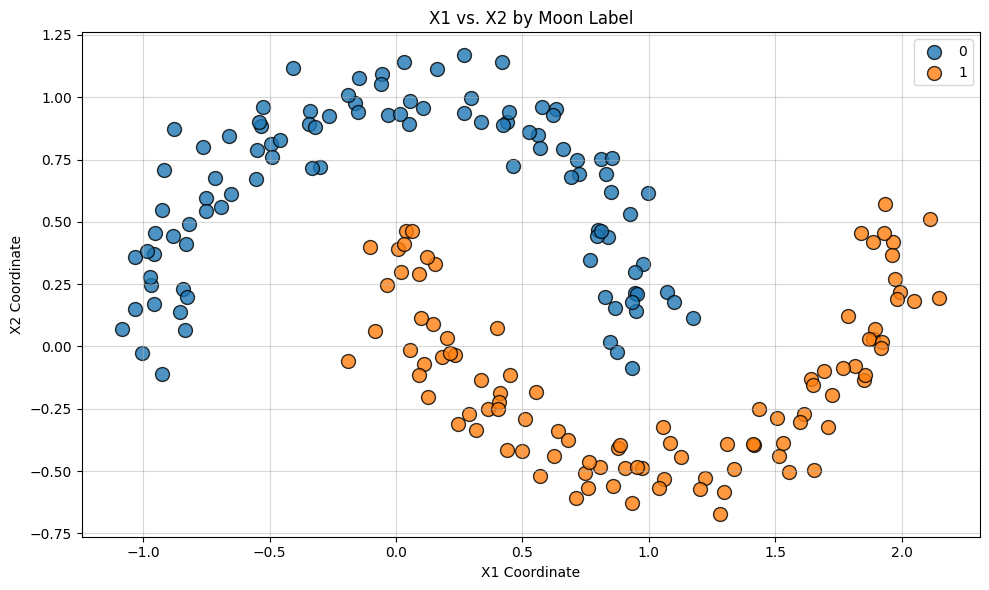

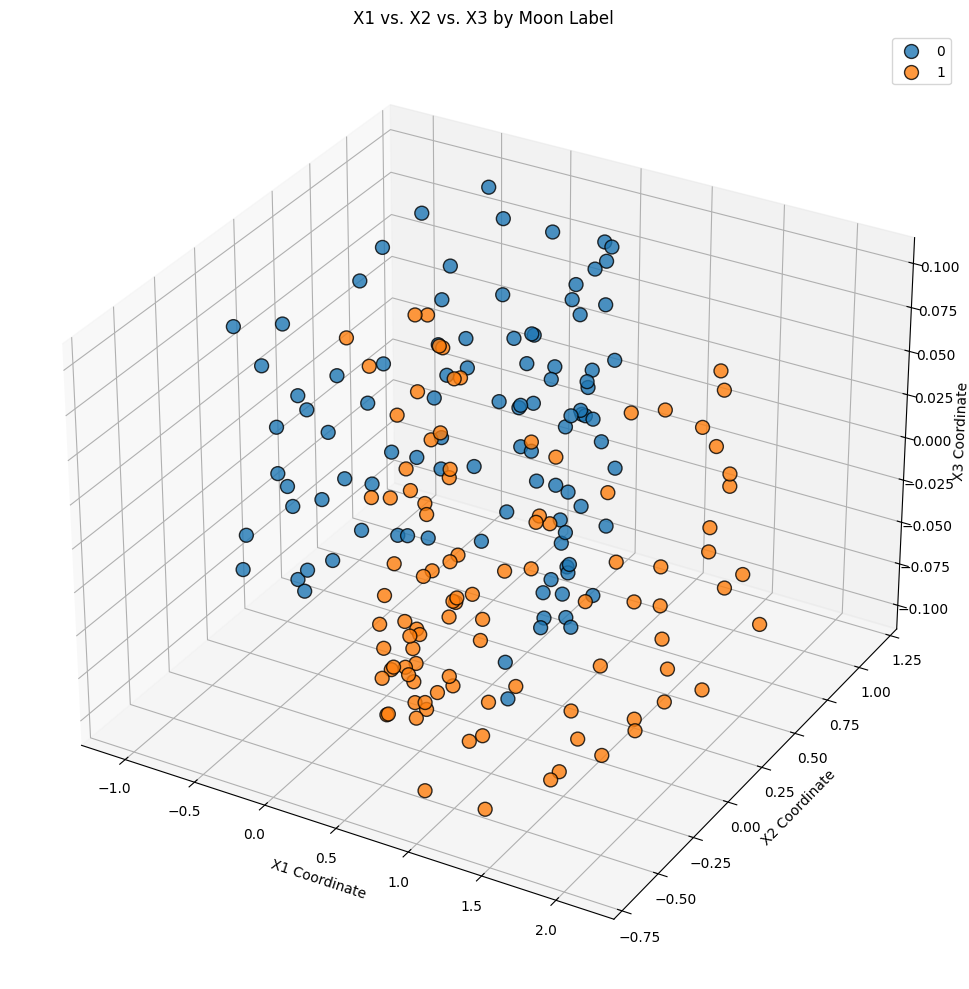

In [6]:
# --- 1. Load Data ---
df = load_dataset('moons')


# --- 2. Data Cleaning ---
df = clean_dataframe(df)

print(df.head(), '\n')


# --- 3. Analysis ---
print("Statistics:")
print(df.describe())

# Average measurements per moon label
moons_stats = df.groupby('label').mean()

print("\nAverage measurements per moon:\n")
print(moons_stats)


# --- 4. Visualization ---
plt.figure(figsize=(10, 6))

for i, (name, group) in enumerate(df.groupby('label')):
    plt.scatter(
        x=group['x1'],
        y=group['x2'],
        label=name,
        edgecolors='black',
        alpha=0.8,
        s=100
    )

plt.title(f"X1 vs. X2 by Moon Label")
plt.xlabel("X1 Coordinate")
plt.ylabel("X2 Coordinate")

plt.grid(alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 10))

ax = plt.subplot(111, projection='3d')

for name, group in df.groupby('label'):
    ax.scatter(
        xs=group['x1'],
        ys=group['x2'],
        zs=group['x3'],
        label=name,
        edgecolors='black',
        alpha=0.8,
        s=100
    )

ax.set_title("X1 vs. X2 vs. X3 by Moon Label")
ax.set_xlabel("X1 Coordinate")
ax.set_ylabel("X2 Coordinate")
ax.set_zlabel("X3 Coordinate")

ax.legend()
plt.tight_layout()
plt.show()

# Obviously, the probelm is not linearly separable, so we can't use a basuc model. We will need a more complex model, like a Decision Tree,
# to capture the non-linear relationships in the data.


Training on 160 samples
Testing on 40 samples

--- Testing Results ---
Accuracy: 92.50%


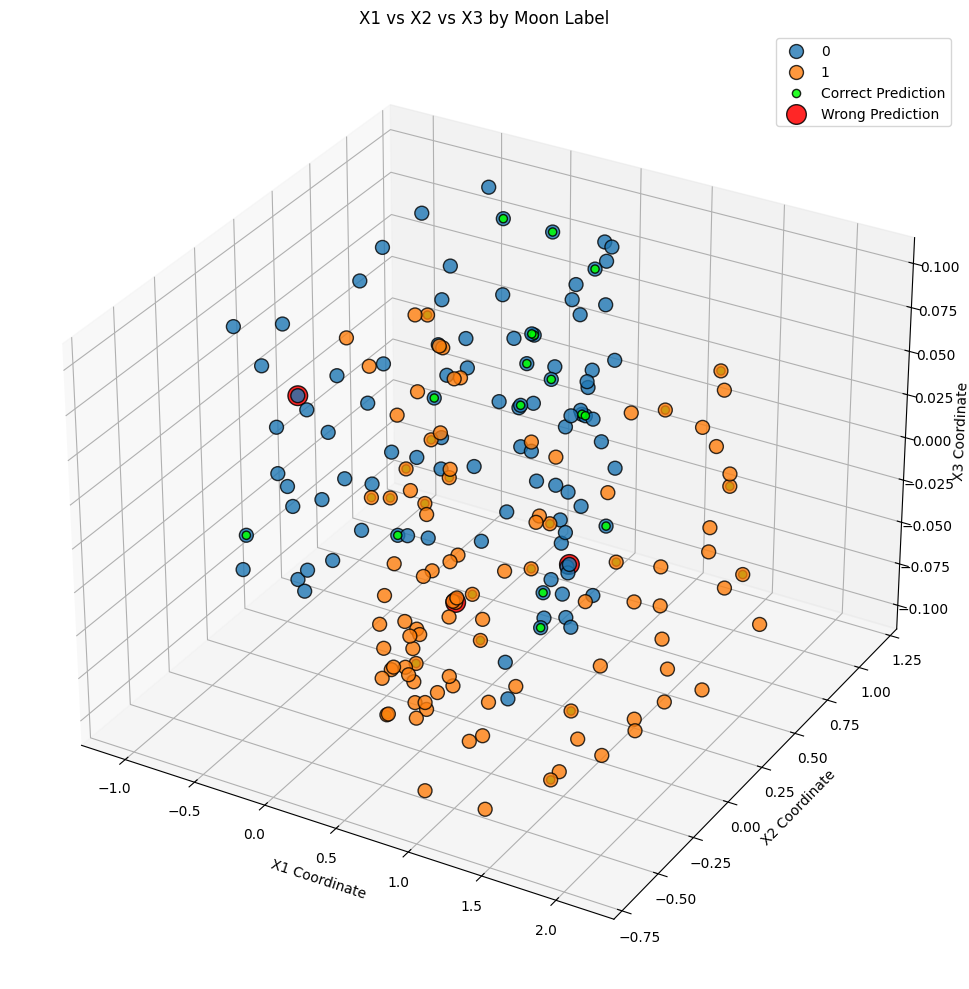

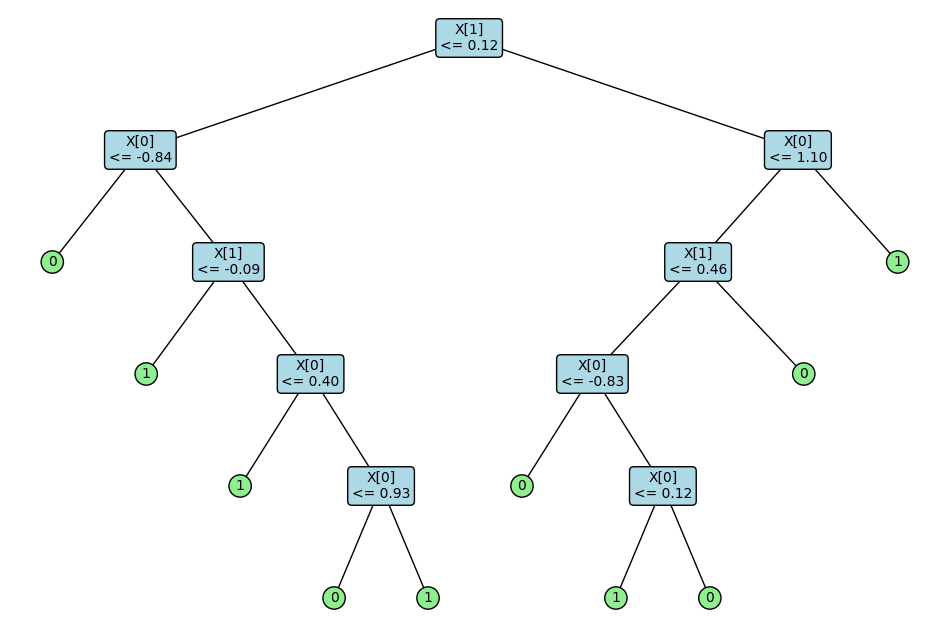

In [7]:
# --- 1. Select Features & Target ---
X = df.drop('label', axis=1).values
y = df['label'].values


# --- 2. Split Data for training & testing ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=None)



# --- 3. Training ---
print(f"Training on {len(X_train)} samples")

model = DecisionTreeClassifier(max_depth=10)
model.fit(X_train, y_train)


# --- 4. Evaluation ---
print(f"Testing on {len(X_test)} samples")

print("\n--- Testing Results ---")
predictions = model.predict(X_test)

accuracy = Metrics.accuracy(y_test, predictions)
print(f"Accuracy: {accuracy * 100:.2f}%")


# --- 5. Visualization ---
fig = plt.figure(figsize=(10, 10))
ax = plt.subplot(111, projection='3d')

for name, group in df.groupby('label'):
    ax.scatter(
        xs=group['x1'],
        ys=group['x2'],
        zs=group['x3'],
        label=name,
        edgecolors='black',
        alpha=0.8,
        s=100
    )


test_x1 = X_test[:, 0]
test_x2 = X_test[:, 1]
test_x3 = X_test[:, 2]

correct_mask = (predictions == y_test)
ax.scatter(
    xs=test_x1[correct_mask],
    ys=test_x2[correct_mask],
    zs=test_x3[correct_mask],
    label="Correct Prediction",
    c='lime',
    edgecolors='black',
    alpha=0.85,
    s=35,
)

wrong_mask = (predictions != y_test)
ax.scatter(
    xs=test_x1[wrong_mask],
    ys=test_x2[wrong_mask],
    zs=test_x3[wrong_mask],
    label="Wrong Prediction",
    c='red',
    edgecolors='black',
    alpha=0.85,
    s=200,
)


ax.set_title("X1 vs X2 vs X3 by Moon Label")
ax.set_xlabel("X1 Coordinate")
ax.set_ylabel("X2 Coordinate")
ax.set_zlabel("X3 Coordinate")

ax.legend()
plt.tight_layout()
plt.show()



model.print_tree()